# Etapa 3 - Aplicação de Algoritmos

Nesta etapa aplicamos algoritmos de clusterização ao conjunto tratado na Etapa 1, usando as conclusões da Etapa 2 como base metodológica.

Os objetivos avaliados são:

- comparar métricas de similaridade/dissimilaridade: Euclidiana, Manhattan e Cosine;
- testar diferentes métodos de clusterização;
- avaliar coesão e separação com Elbow, Silhouette, Davies-Bouldin e Calinski-Harabasz;
- testar estabilidade do K-Means com diferentes sementes por ARI e NMI;
- gerar um arquivo com os rótulos finais para a etapa de visualização.


In [1]:
import os
from itertools import combinations
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-etapa3")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

SEED = 42
COLUNAS_CLUSTER = ["Lat", "Lon", "Hour", "Day"]
K_ESCOLHIDO = 4
K_CANDIDATOS_ESTABILIDADE = [4, 5, 7]
SILHOUETTE_SAMPLE = 5000
AMOSTRA_ALGORITMOS_CAROS = 6000
MIN_SAMPLES_DBSCAN = 10

METRICAS_DISTANCIA = {
    "euclidean": "Euclidiana",
    "manhattan": "Manhattan",
    "cosine": "Cosine",
}

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print("Configuração carregada. Semente:", SEED)


Configuração carregada. Semente: 42


## 1. Carregamento e preparação dos dados

O arquivo tratado possui `Lat`, `Lon` e `Hour` normalizados pela Etapa 1, mas `Day` permanece na escala de 1 a 16. Como os algoritmos desta etapa são baseados em distância, usamos `StandardScaler` para evitar que `Day` domine os agrupamentos.


In [2]:
CAMINHOS_DADOS = [
    Path("../ubernymaio14_tratado.csv"),
    Path("ubernymaio14_tratado.csv"),
]

CAMINHO_DADOS = next((caminho for caminho in CAMINHOS_DADOS if caminho.exists()), None)
if CAMINHO_DADOS is None:
    raise FileNotFoundError("Arquivo 'ubernymaio14_tratado.csv' não encontrado.")

df = pd.read_csv(CAMINHO_DADOS)
X_original = df[COLUNAS_CLUSTER].astype(float)

scaler = StandardScaler()
X = scaler.fit_transform(X_original)

print("Arquivo carregado:", CAMINHO_DADOS)
print("Dimensão dos dados:", X.shape)
print("Colunas usadas no clustering:", COLUNAS_CLUSTER)

resumo_escala = X_original.agg(["min", "max", "mean", "std"]).T
resumo_escala["std_após_padronização"] = X.std(axis=0, ddof=0)
display(resumo_escala)


Arquivo carregado: ../ubernymaio14_tratado.csv
Dimensão dos dados: (19220, 4)
Colunas usadas no clustering: ['Lat', 'Lon', 'Hour', 'Day']


,min,max,mean,std,std_após_padronização
Lat,0.0,1.0,0.403957,0.044659,1.0
Lon,0.0,1.0,0.286349,0.026344,1.0
Hour,0.0,1.0,0.623067,0.237144,1.0
Day,1.0,16.0,8.407388,4.666438,1.0


## 2. Escolha de K: Elbow e Silhouette

Avaliamos `K` de 2 a 10 com K-Means. O Elbow mostra a redução da inércia, enquanto o Silhouette ajuda a identificar separação média entre clusters. A referência técnica inicial do trabalho é silhouette maior ou igual a 0,25.


Avaliação de K por Elbow e métricas de coesão/separação:


,K,Inércia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,62789.6516,0.2250,1.7244,4312.7019
1,3,53073.3560,0.2367,1.3716,4310.0343
2,4,44619.6022,0.2568,1.1588,4631.1208
3,5,39190.7339,0.2679,1.0437,4619.7178
4,6,35263.9279,0.2521,1.1176,4535.1216
5,7,30614.9647,0.2627,1.0186,4839.0830
6,8,28125.7906,0.2475,1.0721,4757.5570
7,9,26134.7446,0.2488,1.0552,4662.7191
8,10,24699.0840,0.2474,1.0965,4509.3750


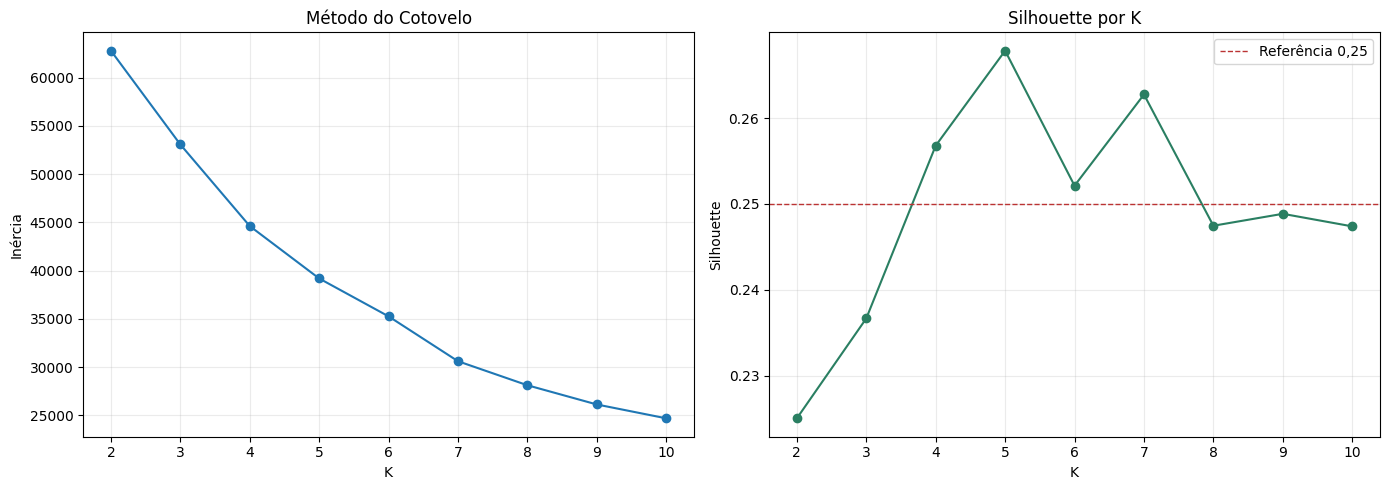

Comparação de estabilidade para candidatos de K:


,K,Silhouette,ARI mínimo entre seeds
0,4,0.2568,0.9960
1,5,0.2679,0.7623
2,7,0.2627,0.9998


Menor K que atende silhouette >= 0,25 e ARI > 0,8: 4
K escolhido para as comparações principais: 4


In [3]:
def silhouette_amostral(X_avaliacao, labels, metric="euclidean"):
    """Calcula silhouette com amostragem para controlar custo de memória."""
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2:
        return np.nan

    sample_size = min(SILHOUETTE_SAMPLE, len(labels))
    if sample_size < len(labels):
        return silhouette_score(
            X_avaliacao,
            labels,
            metric=metric,
            sample_size=sample_size,
            random_state=SEED,
        )
    return silhouette_score(X_avaliacao, labels, metric=metric)


avaliacao_k = []

for k in range(2, 11):
    modelo = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = modelo.fit_predict(X)
    avaliacao_k.append({
        "K": k,
        "Inércia": modelo.inertia_,
        "Silhouette": silhouette_amostral(X, labels, metric="euclidean"),
        "Davies-Bouldin": davies_bouldin_score(X, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X, labels),
    })

avaliacao_k_df = pd.DataFrame(avaliacao_k)
print("Avaliação de K por Elbow e métricas de coesão/separação:")
display(avaliacao_k_df.round(4))

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))
eixos[0].plot(avaliacao_k_df["K"], avaliacao_k_df["Inércia"], marker="o")
eixos[0].set_title("Método do Cotovelo")
eixos[0].set_xlabel("K")
eixos[0].set_ylabel("Inércia")

eixos[1].plot(avaliacao_k_df["K"], avaliacao_k_df["Silhouette"], marker="o", color="#2a7f62")
eixos[1].axhline(0.25, color="#b33", linestyle="--", linewidth=1, label="Referência 0,25")
eixos[1].set_title("Silhouette por K")
eixos[1].set_xlabel("K")
eixos[1].set_ylabel("Silhouette")
eixos[1].legend()

fig.tight_layout()
display(fig)
plt.close(fig)

def ari_minimo_para_k(k, seeds=(0, 1, 2, 42, 100)):
    rotulos = [
        KMeans(n_clusters=k, random_state=seed, n_init=20).fit_predict(X)
        for seed in seeds
    ]
    return min(adjusted_rand_score(a, b) for a, b in combinations(rotulos, 2))


estabilidade_k = []
for k in K_CANDIDATOS_ESTABILIDADE:
    linha_k = avaliacao_k_df.loc[avaliacao_k_df["K"] == k].iloc[0]
    estabilidade_k.append({
        "K": k,
        "Silhouette": linha_k["Silhouette"],
        "ARI mínimo entre seeds": ari_minimo_para_k(k),
    })

estabilidade_k_df = pd.DataFrame(estabilidade_k)
print("Comparação de estabilidade para candidatos de K:")
display(estabilidade_k_df.round(4))

criterios_k = estabilidade_k_df[
    (estabilidade_k_df["Silhouette"] >= 0.25)
    & (estabilidade_k_df["ARI mínimo entre seeds"] > 0.8)
].sort_values("K")
if not criterios_k.empty:
    print("Menor K que atende silhouette >= 0,25 e ARI > 0,8:", int(criterios_k.iloc[0]["K"]))

print(f"K escolhido para as comparações principais: {K_ESCOLHIDO}")


O valor `K=4` é usado como escolha principal por equilibrar qualidade, estabilidade e parcimônia. Na execução local, `K=5` obteve silhouette ligeiramente maior, mas caiu abaixo do critério ideal de estabilidade (`ARI > 0,8`). `K=7` também foi estável, porém aumenta a quantidade de grupos por um ganho pequeno de silhouette. Assim, `K=4` é o menor valor que atende simultaneamente silhouette maior ou igual a `0,25` e ARI maior que `0,8`.


## 3. Funções auxiliares de avaliação

Para DBSCAN, os pontos marcados como ruído (`-1`) são reportados separadamente. As métricas de silhouette, Davies-Bouldin e Calinski-Harabasz são calculadas apenas quando há pelo menos dois clusters válidos.


In [4]:
def criar_aglomerativo(metric, n_clusters=K_ESCOLHIDO, linkage="average"):
    """Compatibiliza versões novas e antigas do scikit-learn."""
    try:
        return AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage, metric=metric)
    except TypeError:
        return AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage, affinity=metric)


def metricas_rotulos(nome, labels, X_avaliacao, metric_silhouette="euclidean", eps=np.nan, ignora_ruido=False):
    labels = np.asarray(labels)
    ruido = labels == -1
    mascara = ~ruido if ignora_ruido else np.ones(len(labels), dtype=bool)

    X_validos = X_avaliacao[mascara]
    labels_validos = labels[mascara]
    clusters_validos = sorted(set(labels_validos) - {-1})
    n_clusters = len(clusters_validos)

    linha = {
        "Algoritmo": nome,
        "Métrica": METRICAS_DISTANCIA.get(metric_silhouette, metric_silhouette),
        "EPS": eps,
        "Clusters": n_clusters,
        "Pontos avaliados": len(labels_validos),
        "% ruído": float(ruido.mean() * 100),
        "Silhouette": np.nan,
        "Davies-Bouldin": np.nan,
        "Calinski-Harabasz": np.nan,
    }

    if n_clusters >= 2 and len(labels_validos) > n_clusters:
        linha["Silhouette"] = silhouette_amostral(X_validos, labels_validos, metric=metric_silhouette)
        linha["Davies-Bouldin"] = davies_bouldin_score(X_validos, labels_validos)
        linha["Calinski-Harabasz"] = calinski_harabasz_score(X_validos, labels_validos)

    return linha


def candidatos_eps_dbscan(X_avaliacao, metric, min_samples=MIN_SAMPLES_DBSCAN):
    n_neighbors = min(min_samples, len(X_avaliacao))
    vizinhos = NearestNeighbors(n_neighbors=n_neighbors, metric=metric)
    vizinhos.fit(X_avaliacao)
    distancias, _ = vizinhos.kneighbors(X_avaliacao)
    k_distancias = np.sort(distancias[:, -1])
    candidatos = np.quantile(k_distancias, [0.80, 0.85, 0.90, 0.95, 0.98])
    return sorted({float(valor) for valor in candidatos if valor > 0})


print("Funções auxiliares definidas: avaliação de rótulos, Agglomerative compatível e candidatos de EPS para DBSCAN.")


Funções auxiliares definidas: avaliação de rótulos, Agglomerative compatível e candidatos de EPS para DBSCAN.


## 4. Comparação das métricas de distância

K-Means otimiza inércia Euclidiana. Ainda assim, avaliamos os mesmos rótulos com Euclidiana, Manhattan e Cosine para medir como a separação muda conforme a noção de distância. Em seguida, testamos Agglomerative e DBSCAN com essas métricas.


In [5]:
kmeans_base = KMeans(n_clusters=K_ESCOLHIDO, random_state=SEED, n_init=20)
labels_kmeans_base = kmeans_base.fit_predict(X)

comparacao_metricas = []
for metrica in METRICAS_DISTANCIA:
    comparacao_metricas.append({
        "Labels": "KMeans",
        "Métrica avaliada": METRICAS_DISTANCIA[metrica],
        "Silhouette": silhouette_amostral(X, labels_kmeans_base, metric=metrica),
    })

comparacao_metricas_df = pd.DataFrame(comparacao_metricas)
print("Silhouette dos rótulos do K-Means avaliado com diferentes métricas de distância:")
display(comparacao_metricas_df.round(4))


Silhouette dos rótulos do K-Means avaliado com diferentes métricas de distância:


,Labels,Métrica avaliada,Silhouette
0,KMeans,Euclidiana,0.2568
1,KMeans,Manhattan,0.2415
2,KMeans,Cosine,0.4130


## 5. Teste de diferentes algoritmos

Agglomerative com métricas Manhattan/Cosine exige cálculo de distâncias par a par. Para manter o notebook executável em máquinas comuns, essa comparação usa uma amostra reprodutível de até 6.000 registros. O K-Means final e o teste de estabilidade usam o conjunto completo.


In [6]:
rng = np.random.default_rng(SEED)
tamanho_amostra = min(AMOSTRA_ALGORITMOS_CAROS, len(X))
indices_amostra = np.sort(rng.choice(len(X), size=tamanho_amostra, replace=False))
X_amostra = X[indices_amostra]

resultados_algoritmos = []

labels_kmeans_amostra = KMeans(n_clusters=K_ESCOLHIDO, random_state=SEED, n_init=20).fit_predict(X_amostra)
resultados_algoritmos.append(
    metricas_rotulos("KMeans", labels_kmeans_amostra, X_amostra, metric_silhouette="euclidean")
)

for metrica in METRICAS_DISTANCIA:
    labels_agg = criar_aglomerativo(metric=metrica).fit_predict(X_amostra)
    resultados_algoritmos.append(
        metricas_rotulos(
            f"Agglomerative Average",
            labels_agg,
            X_amostra,
            metric_silhouette=metrica,
        )
    )

dbscan_grid = []
for metrica in METRICAS_DISTANCIA:
    for eps in candidatos_eps_dbscan(X_amostra, metrica):
        labels_dbscan = DBSCAN(
            eps=eps,
            min_samples=MIN_SAMPLES_DBSCAN,
            metric=metrica,
            n_jobs=-1,
        ).fit_predict(X_amostra)
        dbscan_grid.append(
            metricas_rotulos(
                "DBSCAN",
                labels_dbscan,
                X_amostra,
                metric_silhouette=metrica,
                eps=eps,
                ignora_ruido=True,
            )
        )

dbscan_grid_df = pd.DataFrame(dbscan_grid)
print("Grade de DBSCAN por métrica e EPS candidato:")
display(dbscan_grid_df.sort_values(["Métrica", "EPS"]).round(4))

dbscan_validos = dbscan_grid_df.dropna(subset=["Silhouette"])
for metrica_nome, grupo in dbscan_validos.groupby("Métrica"):
    melhor = grupo.sort_values("Silhouette", ascending=False).iloc[0].to_dict()
    resultados_algoritmos.append(melhor)

resultados_algoritmos_df = pd.DataFrame(resultados_algoritmos)
print("Resumo comparativo dos algoritmos testados:")
display(resultados_algoritmos_df.sort_values("Silhouette", ascending=False).round(4))


Grade de DBSCAN por métrica e EPS candidato:


,Algoritmo,Métrica,EPS,Clusters,Pontos avaliados,% ruído,Silhouette,Davies-Bouldin,Calinski-Harabasz
10,DBSCAN,Cosine,0.0180,13,5433,9.4500,-0.4969,1.4723,110.1776
11,DBSCAN,Cosine,0.0216,8,5588,6.8667,-0.3656,1.3856,189.6097
12,DBSCAN,Cosine,0.0280,6,5795,3.4167,-0.3085,1.2217,180.7058
13,DBSCAN,Cosine,0.0373,1,5915,1.4167,NaN,NaN,NaN
14,DBSCAN,Cosine,0.0529,1,5977,0.3833,NaN,NaN,NaN
0,DBSCAN,Euclidiana,0.4337,7,5202,13.3000,0.0337,0.8201,98.1429
1,DBSCAN,Euclidiana,0.4934,6,5450,9.1667,0.0927,0.8012,177.5324
2,DBSCAN,Euclidiana,0.6037,4,5649,5.8500,0.2602,0.9690,336.6851
3,DBSCAN,Euclidiana,0.8514,3,5805,3.2500,0.4751,0.7452,493.9312
4,DBSCAN,Euclidiana,1.5217,2,5917,1.3833,0.4612,0.8721,399.0987


Resumo comparativo dos algoritmos testados:


,Algoritmo,Métrica,EPS,Clusters,Pontos avaliados,% ruído,Silhouette,Davies-Bouldin,Calinski-Harabasz
1,Agglomerative Average,Euclidiana,NaN,4,6000,0.0000,0.7057,0.6625,231.7167
2,Agglomerative Average,Manhattan,NaN,4,6000,0.0000,0.7018,0.4982,182.3579
6,DBSCAN,Manhattan,1.2851,3,5803,3.2833,0.5028,0.7559,511.4909
5,DBSCAN,Euclidiana,0.8514,3,5805,3.2500,0.4751,0.7452,493.9312
3,Agglomerative Average,Cosine,NaN,4,6000,0.0000,0.3646,1.7741,1040.1061
0,KMeans,Euclidiana,NaN,4,6000,0.0000,0.2708,1.1554,1416.9868
4,DBSCAN,Cosine,0.0280,6,5795,3.4167,-0.3085,1.2217,180.7058


## 6. Estabilidade do K-Means

A estabilidade é medida comparando os rótulos obtidos com diferentes sementes. ARI e NMI próximos de 1 indicam soluções muito semelhantes. Como referência do enunciado, ARI maior que 0,8 é desejável.


In [7]:
seeds = [0, 1, 2, 42, 100]
rotulos_por_seed = {}

for seed in seeds:
    modelo = KMeans(n_clusters=K_ESCOLHIDO, random_state=seed, n_init=20)
    rotulos_por_seed[seed] = modelo.fit_predict(X)

linhas_estabilidade = []
for seed_a, seed_b in combinations(seeds, 2):
    labels_a = rotulos_por_seed[seed_a]
    labels_b = rotulos_por_seed[seed_b]
    linhas_estabilidade.append({
        "Seed A": seed_a,
        "Seed B": seed_b,
        "ARI": adjusted_rand_score(labels_a, labels_b),
        "NMI": normalized_mutual_info_score(labels_a, labels_b),
    })

estabilidade_df = pd.DataFrame(linhas_estabilidade)
display(estabilidade_df.round(4))

print("ARI mínimo:", round(estabilidade_df["ARI"].min(), 4))
print("NMI mínimo:", round(estabilidade_df["NMI"].min(), 4))
print("Estável pelo critério ARI > 0,8:", bool((estabilidade_df["ARI"] > 0.8).all()))


,Seed A,Seed B,ARI,NMI
0,0,1,0.9985,0.9966
1,0,2,0.9997,0.9992
2,0,42,0.9997,0.9992
3,0,100,0.9975,0.9947
4,1,2,0.9982,0.9961
5,1,42,0.9988,0.9972
6,1,100,0.9960,0.9920
7,2,42,0.9994,0.9986
8,2,100,0.9978,0.9952
9,42,100,0.9972,0.9941


ARI mínimo: 0.996
NMI mínimo: 0.992
Estável pelo critério ARI > 0,8: True


## 7. Exportação dos clusters finais

O arquivo `clusters_etapa3.csv` salva os rótulos finais do K-Means no conjunto completo padronizado. Quando o arquivo original está disponível, também salvamos `Lat_original` e `Lon_original` para permitir mapas geográficos reais no notebook de visualização.


In [8]:
modelo_final = KMeans(n_clusters=K_ESCOLHIDO, random_state=SEED, n_init=20)
labels_finais = modelo_final.fit_predict(X)

clusters_df = df[["Date/Time", "Base", "Lat", "Lon", "Hour", "Day"]].copy()
clusters_df["cluster_kmeans"] = labels_finais.astype(int)

CAMINHOS_ORIGINAL = [
    Path("../ubernymaio14.csv"),
    Path("ubernymaio14.csv"),
]
CAMINHO_ORIGINAL = next((caminho for caminho in CAMINHOS_ORIGINAL if caminho.exists()), None)

if CAMINHO_ORIGINAL is not None:
    df_original_bruto = pd.read_csv(CAMINHO_ORIGINAL, nrows=20000).drop_duplicates().reset_index(drop=True)
    if len(df_original_bruto) == len(clusters_df):
        clusters_df["Lat_original"] = df_original_bruto["Lat"].to_numpy()
        clusters_df["Lon_original"] = df_original_bruto["Lon"].to_numpy()
    else:
        print("Coordenadas originais não foram anexadas: quantidade de linhas diferente após tratamento.")

saida_cluster = Path("clusters_etapa3.csv")
if Path.cwd().name != "etapa3" and Path("etapa3").exists():
    saida_cluster = Path("etapa3") / saida_cluster

clusters_df.to_csv(saida_cluster, index=False)
print("Arquivo salvo em:", saida_cluster)
display(clusters_df.head())


Arquivo salvo em: clusters_etapa3.csv


,Date/Time,Base,Lat,Lon,Hour,Day,cluster_kmeans,Lat_original,Lon_original
0,2014-05-01 00:02:00,B02512,0.411657,0.280886,0.0,1,3,40.7521,-73.9914
1,2014-05-01 00:06:00,B02512,0.343719,0.289346,0.0,1,3,40.6965,-73.9715
2,2014-05-01 00:15:00,B02512,0.404692,0.284117,0.0,1,3,40.7464,-73.9838
3,2014-05-01 00:17:00,B02512,0.404570,0.276762,0.0,1,3,40.7463,-74.0011
4,2014-05-01 00:17:00,B02512,0.420577,0.288538,0.0,1,3,40.7594,-73.9734


## 8. Conclusões da execução

A execução registrada neste notebook permite concluir:

- `K=4` foi escolhido para o K-Means final por ser o menor candidato que atende simultaneamente silhouette maior ou igual a `0,25` e ARI maior que `0,8`;
- na avaliação dos rótulos do K-Means, Cosine apresentou maior silhouette (`0,4130`), enquanto a Euclidiana é a métrica otimizada diretamente pelo algoritmo (`0,2568`);
- Agglomerative e DBSCAN foram testados como métodos alternativos em amostra reprodutível de 6.000 registros, reportando quantidade de clusters e percentual de ruído;
- o DBSCAN teve melhor resultado amostral com Manhattan, silhouette `0,5028`, 3 clusters e cerca de `3,28%` de ruído;
- o K-Means final foi estável: ARI mínimo `0,996` e NMI mínimo `0,992` entre as sementes `[0, 1, 2, 42, 100]`.

Pelos critérios do enunciado, uma solução inicial aceitável deve buscar silhouette maior ou igual a 0,25 e ARI entre execuções acima de 0,8.
